In [152]:
import re
import time
import hashlib
import unicodedata
import warnings
from collections import Counter, defaultdict
from datetime import datetime
from sentence_transformers import SentenceTransformer
import numpy as np
import pandas as pd
import requests
import feedparser
import trafilatura
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 80)


In [153]:
SOURCES = {
    "prothomalo": {
        "display_name": "প্রথম আলো (Prothom Alo)",
        "feeds": ["https://www.prothomalo.com/feed"],
    },
    "bdnews24_bangla": {
        "display_name": "বিডিনিউজ২৪ (bdnews24 Bangla)",
        "feeds": ["https://bangla.bdnews24.com/rss.xml"],
    },
    "kalerkantho": {
        "display_name": "কালের কণ্ঠ (Kaler Kantho)",
        "feeds": ["https://www.kalerkantho.com/rss.xml"],
    },
    "jugantor": {
        "display_name": "যুগান্তর (Jugantor)",
        "feeds": ["https://www.jugantor.com/rss.xml"],
    },
    "ittefaq": {
        "display_name": "দৈনিক ইত্তেফাক (Ittefaq)",
        "feeds": ["https://www.ittefaq.com.bd/rss.xml"],
    },
}

USER_AGENT = ("Mozilla/5.0 (compatible; BanglaNewsIntelBot/0.1; "
              "portfolio research project)")
REQUEST_TIMEOUT = 15
REQUEST_DELAY = 1.0
MAX_ARTICLES_PER_FEED = 40


In [154]:
def check_feed(url):
    try:
        resp = requests.get(url, headers={"User-Agent": USER_AGENT}, timeout=REQUEST_TIMEOUT)
        parsed = feedparser.parse(resp.content)
        title = parsed.feed.get("title") if parsed.feed else None
        if parsed.bozo:
            # If the feed is "bozo" (malformed), print the exception for debugging
            print(f"  Feedparser bozo_exception for {url}: {parsed.bozo_exception}")
        return len(parsed.entries), title
    except requests.exceptions.RequestException as e:
        # Catch specific requests exceptions to differentiate network issues
        return 0, f"requests error: {e}"
    except Exception as e:
        # Catch other general exceptions during parsing
        return 0, f"parsing error: {e}"

print(f"{'source':<18}{'entries':<10}feed_title / error")
print("-" * 70)
for key, cfg in SOURCES.items():
    for feed_url in cfg["feeds"]:
        n, title = check_feed(feed_url)
        flag = "DEAD" if n == 0 else "✅"
        print(f"{key:<18}{n:<10}{flag}  {title}")

source            entries   feed_title / error
----------------------------------------------------------------------
prothomalo        71        ✅  প্রথম আলো
  Feedparser bozo_exception for https://bangla.bdnews24.com/rss.xml: <unknown>:16:4: undefined entity
bdnews24_bangla   0         DEAD  None
  Feedparser bozo_exception for https://www.kalerkantho.com/rss.xml: <unknown>:69:50: undefined entity
kalerkantho       0         DEAD  None
  Feedparser bozo_exception for https://www.jugantor.com/rss.xml: <unknown>:2:1326: not well-formed (invalid token)
jugantor          0         DEAD  None
  Feedparser bozo_exception for https://www.ittefaq.com.bd/rss.xml: <unknown>:2:1326: not well-formed (invalid token)
ittefaq           0         DEAD  None


In [155]:
def collect_feed_items(source_key):
    """Return a list of dicts: url, title, category_hint, published_at (from RSS)."""
    items, seen = [], set()
    for feed_url in SOURCES[source_key]["feeds"]:
        try:
            resp = requests.get(feed_url, headers={"User-Agent": USER_AGENT}, timeout=REQUEST_TIMEOUT)
            parsed = feedparser.parse(resp.content)
        except Exception as e:
            print(f"  feed fetch failed for {feed_url}: {e}")
            continue

        for entry in parsed.entries:
            link = getattr(entry, "link", None)
            if not link or link in seen:
                continue
            seen.add(link)
            published_at = None
            for field in ("published_parsed", "updated_parsed"):
                val = getattr(entry, field, None)
                if val:
                    published_at = datetime(*val[:6])
                    break
            category_hint = None
            if getattr(entry, "tags", None):
                category_hint = entry.tags[0].get("term")
            items.append({
                "source": source_key,
                "url": link,
                "title": getattr(entry, "title", None),
                "category_hint": category_hint,
                "published_at": published_at,
            })
    return items
def extract_article(url):
    """Fetch + extract clean article text/metadata via trafilatura. Returns dict or None."""
    try:
        resp = requests.get(url, headers={"User-Agent": USER_AGENT}, timeout=REQUEST_TIMEOUT)
        resp.raise_for_status()
    except Exception:
        return None
    result = trafilatura.extract(resp.text, include_comments=False, include_tables=False, output_format="json", with_metadata=True, url=url)
    if not result:
        return None
    import json
    data = json.loads(result)
    body = data.get("text")
    if not body or len(body.strip()) < 200:
        return None
    published_at = None
    if data.get("date"):
        try:
            published_at = datetime.fromisoformat(data["date"])
        except ValueError:
            pass
    return {
        "title": data.get("title"),
        "body": body,
        "author": data.get("author"),
        "published_at": published_at,
    }


In [156]:
BANGLA_DIGIT_MAP = str.maketrans("০১২৩৪৫৬৭৮৯", "0123456789")
BOILERPLATE_RE = re.compile(
    r"আরও পড়ুন[:।]?.*|আরো পড়ুন[:।]?.*|সম্পর্কিত খবর[:।]?.*|বিজ্ঞাপন|Advertisement|Also [Rr]ead:.*"
)
def clean_bangla_text(text, normalize_digits=False):
    if not text:
        return ""
    text = unicodedata.normalize("NFC", text)
    lines = [ln for ln in text.split("\n") if not BOILERPLATE_RE.search(ln)]
    text = "\n".join(lines)
    text = re.sub(r"[ \t\u00A0]+", " ", text)
    text = re.sub(r"\n{3,}", "\n\n", text).strip()
    if normalize_digits:
        text = text.translate(BANGLA_DIGIT_MAP)
    return text


In [157]:
rows = []
for source_key in SOURCES:
    print(f"=== {source_key} ===")
    feed_items = collect_feed_items(source_key)[:MAX_ARTICLES_PER_FEED]
    print(f"  {len(feed_items)} candidate URLs from feed")
    for item in feed_items:
        extracted = extract_article(item["url"])
        if extracted is None:
            continue
        rows.append({
            "source": source_key,
            "url": item["url"],
            "url_hash": hashlib.sha256(item["url"].encode()).hexdigest(),
            "title": extracted["title"] or item["title"],
            "body": extracted["body"],
            "cleaned_text": clean_bangla_text(extracted["body"]),
            "author": extracted["author"],
            "category_hint": item["category_hint"],
            "published_at": extracted["published_at"] or item["published_at"],
        })
        time.sleep(REQUEST_DELAY)
    print(f"  {len([r for r in rows if r['source']==source_key])} articles extracted so far")

articles_df = pd.DataFrame(rows).drop_duplicates(subset="url_hash").reset_index(drop=True)

if not articles_df.empty and 'published_at' in articles_df.columns:
    articles_df["published_at"] = pd.to_datetime(articles_df["published_at"])
else:
    print("Warning: No articles collected or 'published_at' column is missing, skipping datetime conversion.")

print(f"\nTotal articles collected: {len(articles_df)}")
articles_df.head()

=== prothomalo ===
  40 candidate URLs from feed
  38 articles extracted so far
=== bdnews24_bangla ===
  0 candidate URLs from feed
  0 articles extracted so far
=== kalerkantho ===
  0 candidate URLs from feed
  0 articles extracted so far
=== jugantor ===
  0 candidate URLs from feed
  0 articles extracted so far
=== ittefaq ===
  0 candidate URLs from feed
  0 articles extracted so far

Total articles collected: 38


,source,url,url_hash,title,body,cleaned_text,author,category_hint,published_at
0,prothomalo,https://www.prothomalo.com/bangladesh/fbpxiw7751,ad64a8b84fac1e7c4ed26a553066492cbe5adaf8376e0ae372cc7d0346007a44,রডের বদলে বাঁশসহ সেতু নির্মাণে অনিয়ম: এলজিইডির তিন কর্মকর্তা–কর্মচারী সাময়...,রডের বদলে বাঁশসহ সেতু নির্মাণে অনিয়ম: এলজিইডির তিন কর্মকর্তা–কর্মচারী সাময়...,রডের বদলে বাঁশসহ সেতু নির্মাণে অনিয়ম: এলজিইডির তিন কর্মকর্তা–কর্মচারী সাময়...,নিজস্ব প্রতিবেদক,স্থানীয় সরকার,2026-09-24
1,prothomalo,https://nagorik.prothomalo.com/durporobash/8i4honfu0r,b80674c80f52a138bdbda356d0c287f448a19e55b99ab5e4cd9e53672e4019c7,৬৪৮ ভোটেই সুইডেনের পার্লামেন্টে!,৬৪৮ ভোটেই সুইডেনের পার্লামেন্টে!\nমাত্র ৬৪৮ ভোট পেয়ে কেউ জাতীয় সংসদের সদস্...,৬৪৮ ভোটেই সুইডেনের পার্লামেন্টে!\nমাত্র ৬৪৮ ভোট পেয়ে কেউ জাতীয় সংসদের সদস্...,লেখ,নির্বাচন,2026-09-24
2,prothomalo,https://www.prothomalo.com/opinion/column/y6xwewjv7u,cb8157d64a050987a3632388f9323d890ca1fa4d57e67a72ae00b104e6daeaf8,"অপ্রতিম হত্যা, টিকটকের ‘গ্যাং’ এবং আমাদের দায়",নেটফ্লিক্সের ‘অ্যাডোলেসেন্স’ দেখার পর অনেক দিন মাথা থেকে যায়নি তেরো বছরের জ...,নেটফ্লিক্সের ‘অ্যাডোলেসেন্স’ দেখার পর অনেক দিন মাথা থেকে যায়নি তেরো বছরের জ...,লেখ,অপ্রতিম হত্যা,2026-09-24
3,prothomalo,https://www.prothomalo.com/education/admission/kkk5j4rdu7,a84752dee5df65f923aba74672917639d7e2fdd91d6ae521eff1b3a3bf962e7c,একাদশ শ্রেণিতে অনলাইন ভর্তির সময় বাড়ল,একাদশ শ্রেণিতে অনলাইন ভর্তির সময় বাড়ল\n২০২৬-২৭ শিক্ষাবর্ষে একাদশ শ্রেণিতে ...,একাদশ শ্রেণিতে অনলাইন ভর্তির সময় বাড়ল\n২০২৬-২৭ শিক্ষাবর্ষে একাদশ শ্রেণিতে ...,নিজস্ব প্রতিবেদক,জেনে রাখো,2026-09-24
4,prothomalo,https://www.prothomalo.com/bangladesh/district/pmk5jyvtx3,50a179f51f54f812a40f3bf9d8bc3cb90f7df2d3e622ac4383bddb4d530ce6bc,"কালিয়াকৈরে দুই কলোনিতে আগুন, পুড়েছে ২৩ কক্ষ ও ৫ দোকান","কালিয়াকৈরে দুই কলোনিতে আগুন, পুড়েছে ২৩ কক্ষ ও ৫ দোকান\nগাজীপুরের কালিয়াকৈ...","কালিয়াকৈরে দুই কলোনিতে আগুন, পুড়েছে ২৩ কক্ষ ও ৫ দোকান\nগাজীপুরের কালিয়াকৈ...",প্রতিনিধ,দুর্ঘটনা,2026-09-24


In [158]:
articles_df.to_csv("articles_raw.csv", index=False)
print("Saved articles_raw.csv —", len(articles_df), "articles")


Saved articles_raw.csv — 38 articles


In [159]:
articles_df = pd.read_csv("articles_raw.csv", parse_dates=["published_at"])
print(len(articles_df), "articles loaded from checkpoint")

38 articles loaded from checkpoint


In [160]:
embed_model = SentenceTransformer("paraphrase-multilingual-mpnet-base-v2")
texts = articles_df["cleaned_text"].fillna("").tolist()
embeddings = embed_model.encode(texts, batch_size=16, show_progress_bar=True, normalize_embeddings=True)
embeddings = np.asarray(embeddings)
np.save("embeddings.npy", embeddings)
print("Embeddings shape:", embeddings.shape)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Embeddings shape: (38, 768)


In [161]:
def assign_event_clusters(df, embeddings, time_col="published_at",
                           sim_threshold=0.55, time_window_hours=72):
    order = np.argsort(df[time_col].values)
    n = len(df)
    cluster_id = np.full(n, -1, dtype=int)
    active = []
    next_id = 0
    for idx in order:
        vec = embeddings[idx]
        t = df[time_col].values[idx]
        best_sim, best_cluster = -1.0, None
        for c in active:
            hours_gap = (t - c["last_time"]) / np.timedelta64(1, "h")
            if hours_gap > time_window_hours:
                continue
            sim = float(np.dot(vec, c["centroid"]) /
                        (np.linalg.norm(vec) * np.linalg.norm(c["centroid"]) + 1e-9))
            if sim > best_sim:
                best_sim, best_cluster = sim, c
        if best_cluster is not None and best_sim >= sim_threshold:
            c = best_cluster
            c["centroid"] = (c["centroid"] * c["count"] + vec) / (c["count"] + 1)
            c["count"] += 1
            c["last_time"] = t
            cluster_id[idx] = c["id"]
        else:
            new_c = {"id": next_id, "centroid": vec.copy(), "count": 1, "last_time": t}
            active.append(new_c)
            cluster_id[idx] = next_id
            next_id += 1
        active = [c for c in active if (t - c["last_time"]) / np.timedelta64(1, "h") <= time_window_hours]
    return cluster_id
articles_df["cluster_id"] = assign_event_clusters(articles_df, embeddings, sim_threshold=0.55, time_window_hours=72)

cluster_sizes = articles_df["cluster_id"].value_counts()
print(f"{len(cluster_sizes)} event clusters found from {len(articles_df)} articles")
print("\nBiggest clusters right now (= 'what is happening'):")
for cid, size in cluster_sizes.head(10).items():
    sample_titles = articles_df[articles_df.cluster_id == cid]["title"].head(2).tolist()
    print(f"  cluster {cid} ({size} articles): {sample_titles}")


28 event clusters found from 38 articles

Biggest clusters right now (= 'what is happening'):
  cluster 0 (6 articles): ['রডের বদলে বাঁশসহ সেতু নির্মাণে অনিয়ম: এলজিইডির তিন কর্মকর্তা–কর্মচারী সাময়িক বরখাস্ত', 'নীলফামারী জেলা প্রশাসকের অধীন চাকরি, পদ ১২']
  cluster 10 (2 articles): ['৬৪৮ ভোটেই সুইডেনের পার্লামেন্টে!', 'ভোটার স্থানান্তর কার্যক্রম আবার চালু করল ইসি']
  cluster 9 (2 articles): ['অপ্রতিম হত্যা, টিকটকের ‘গ্যাং’ এবং আমাদের দায়', 'গাঢ়বুক ছাতারের খোঁজে']
  cluster 13 (2 articles): ['ভারতে ব্রিকস সম্মেলন: নিরামিষভোজনের নামে হিন্দুত্ববাদী রাজনীতি', 'নিউইয়র্কে প্রধানমন্ত্রীর ব্যস্ততা']
  cluster 15 (2 articles): ['এলপিজি সংকট, বেড়েছে দামও, কী কারণ', 'আজকের বিনিময় হার']
  cluster 11 (2 articles): ['বয়ঃসন্ধিকালে সন্তানদের আচরণগত পরিবর্তনে অভিভাবকদের করণীয়', 'রাজশাহী বিশ্ববিদ্যালয়ে র্যাগিংয়ে জড়িত ১৫ শিক্ষার্থীকে বহিষ্কার, ৮০ জনকে সতর্কবার্তা']
  cluster 18 (1 articles): ['দৈনন্দিন লেনদেনে ইসলামের ৬ নির্দেশনা মেনে চলুন']
  cluster 16 (1 articles): ['একাদশ শ্রেণিতে অনলাইন ভ

In [162]:
from transformers import pipeline as hf_pipeline

ner_pipe = hf_pipeline(
    "token-classification",
    model="engineersakibcse47/NER_on_Bangla_Language",
    aggregation_strategy="simple",
)
def extract_entities(text, max_chars=2000):
    """Truncate long articles — NER models have a token limit, and the
    opening paragraphs of a news article usually carry the key entities anyway."""
    if not text:
        return []
    truncated = text[:max_chars]
    try:
        ents = ner_pipe(truncated)
    except Exception:
        return []

    results = []
    for e in ents:
        if "start" in e and "end" in e:
            name = truncated[e["start"]:e["end"]].strip()
        else:
            name = e["word"].strip()
        if name:
            results.append((name, e["entity_group"]))
    return results
def extract_entities(text, max_chars=2000):
    """Truncate long articles — NER models have a token limit, and the
    opening paragraphs of a news article usually carry the key entities anyway."""
    if not text:
        return []
    try:
        ents = ner_pipe(text[:max_chars])
    except Exception:
        return []
    return [(e["word"].strip(), e["entity_group"]) for e in ents if e["word"].strip()]
sample_entities = extract_entities(articles_df["cleaned_text"].iloc[0])
print("Sample entities from first article:", sample_entities)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Sample entities from first article: [('নোয়াখালী', 'LOC'), ('টাঙ্গাইলে', 'LOC'), ('##ীয়', 'LOC'), ('নোয়াখালীর', 'LOC'), ('বে', 'LOC'), ('##মগঞ্জের', 'LOC'), ('টাঙ্গাইলের', 'LOC'), ('##োয়া', 'LOC'), ('##র', 'LOC'), ('উপজেলা', 'LOC'), ('ম', 'PER'), ('বেলাল হোসেনের', 'PER'), ('নোয়াখালীর', 'LOC'), ('বেগমগঞ্জে', 'LOC'), ('প্রথম আলোয়', 'ORG'), ('##েগমগঞ্জ উপজেলা', 'LOC'), ('ম', 'PER'), ('নাজমুল ইসলাম', 'PER'), ('মহিন উদ্দিন', 'PER')]


In [163]:
from google.colab import userdata

# Retrieve your Hugging Face token from Colab secrets
# If you don't have one, please add it to Colab secrets under the name 'HF_TOKEN'
HF_TOKEN = userdata.get('HF_TOKEN')

In [164]:
articles_df["entities"] = articles_df["cleaned_text"].apply(extract_entities)
all_entities = Counter()
for ents in articles_df["entities"]:
    for name, etype in ents:
        all_entities[(name, etype)] += 1
print("Top 20 most-mentioned entities overall:")
for (name, etype), count in all_entities.most_common(20):
    print(f"  {name:<30} [{etype}]  {count} mentions")


Top 20 most-mentioned entities overall:
  বাংলাদেশের                     [LOC]  9 mentions
  ভারতের                         [LOC]  6 mentions
  নিউইয়র্কে                     [LOC]  6 mentions
  বাংলাদেশ                       [LOC]  5 mentions
  জাতীয়                         [ORG]  4 mentions
  তারেক রহমানের                  [PER]  4 mentions
  ম                              [PER]  3 mentions
  ##ার                           [ORG]  3 mentions
  আবু জরের                       [PER]  3 mentions
  ##ের                           [ORG]  3 mentions
  যুক্তরাষ্ট্রে                  [LOC]  3 mentions
  নোয়াখালীর                     [LOC]  2 mentions
  ##র                            [LOC]  2 mentions
  সুইডেনের                       [LOC]  2 mentions
  কুমিল্লা                       [LOC]  2 mentions
  প্রথম আলোর                     [ORG]  2 mentions
  ফ                              [ORG]  2 mentions
  ##ার্ভিসের                     [ORG]  2 mentions
  চীনের                          [LOC]  2 

In [165]:
from transformers import pipeline

sentiment_pipe = hf_pipeline(
    "text-classification",
    model="sagorsarker/bangla-bert-base",
    token=HF_TOKEN
)
test_result = sentiment_pipe(articles_df["cleaned_text"].iloc[0][:512])
print("Raw output on a sample article:", test_result)
print("\n Check the 'label' value above, then fix LABEL_MAP below if needed before running the next cell.")
LABEL_MAP = {
    "positive": 1, "negative": -1, "neutral": 0,
    "LABEL_0": -1, "LABEL_1": 1,
}

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: sagorsarker/bangla-bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Raw output on a sample article: [{'label': 'LABEL_1', 'score': 0.5271357893943787}]

 Check the 'label' value above, then fix LABEL_MAP below if needed before running the next cell.


In [166]:
sentiment_pipe = hf_pipeline("text-classification", model="sagorsarker/bangla-bert-base", token=HF_TOKEN)
test_result = sentiment_pipe(articles_df["cleaned_text"].iloc[0][:512])
print("Raw output on a sample article:", test_result)
print("\n Check the 'label' value above, then fix LABEL_MAP below if needed before running the next cell.")
LABEL_MAP = {
    "positive": 1, "negative": -1, "neutral": 0,
    "LABEL_0": -1, "LABEL_1": 1,
}

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: sagorsarker/bangla-bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Raw output on a sample article: [{'label': 'LABEL_0', 'score': 0.6029388308525085}]

 Check the 'label' value above, then fix LABEL_MAP below if needed before running the next cell.


In [167]:
def get_sentiment(text):
    if not text:
        return None, None
    try:
        result = sentiment_pipe(text[:512])[0]
    except Exception:
        return None, None
    label = result["label"]
    score = result["score"] * LABEL_MAP.get(label, 0)
    return label, score

sentiments = articles_df["cleaned_text"].apply(get_sentiment)
articles_df["sentiment_label"] = sentiments.apply(lambda x: x[0])
articles_df["sentiment_score"] = sentiments.apply(lambda x: x[1])

print("Average sentiment score by source:")
print(articles_df.groupby("source")["sentiment_score"].mean().sort_values())


Average sentiment score by source:
source
prothomalo   -0.309831
Name: sentiment_score, dtype: float64


In [175]:
!pip install -q stopwordsiso

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.9/74.9 kB 988.8 kB/s eta 0:00:00


In [176]:
from sklearn.feature_extraction.text import TfidfVectorizer
import stopwordsiso as stopwords_iso

BANGLA_STOPWORDS = list(stopwords_iso.stopwords("bn"))
print(f"{len(BANGLA_STOPWORDS)} stopwords loaded")
def top_terms_for_window(df_window, top_n=15):
    texts = df_window["cleaned_text"].fillna("").tolist()
    if len(texts) < 3:
        return []
    vec = TfidfVectorizer(max_features=2000, stop_words=BANGLA_STOPWORDS, ngram_range=(1, 2), token_pattern=r"[ঀ-৿a-zA-Z0-9]+")
    tfidf = vec.fit_transform(texts)
    scores = np.asarray(tfidf.sum(axis=0)).ravel()
    terms = vec.get_feature_names_out()
    ranked = sorted(zip(terms, scores), key=lambda x: -x[1])[:top_n]
    return ranked
def find_emerging_topics(df, window_days=2, top_n=10):
    """Compare the most recent window's top terms against the prior window;
    'emerging' = rising sharply in the recent window vs. the one before it."""
    df = df.dropna(subset=["published_at"]).sort_values("published_at")
    if df.empty:
        return []
    latest = df["published_at"].max()
    recent_cutoff = latest - pd.Timedelta(days=window_days)
    prior_cutoff = recent_cutoff - pd.Timedelta(days=window_days)
    recent = df[df.published_at >= recent_cutoff]
    prior = df[(df.published_at >= prior_cutoff) & (df.published_at < recent_cutoff)]

    recent_terms = dict(top_terms_for_window(recent, top_n=50))
    prior_terms = dict(top_terms_for_window(prior, top_n=50))
    emerging = []
    for term, score in recent_terms.items():
        prior_score = prior_terms.get(term, 0.01)
        growth = score / prior_score
        emerging.append((term, score, growth))
    emerging.sort(key=lambda x: -x[2])
    return emerging[:top_n]


emerging = find_emerging_topics(articles_df, window_days=2, top_n=10)
print("Emerging topics (term, recent tf-idf score, growth ratio vs. prior window):")
for term, score, growth in emerging:
    print(f"  {term:<25} score={score:.2f}  growth={growth:.1f}x")


398 stopwords loaded
Emerging topics (term, recent tf-idf score, growth ratio vs. prior window):
  এক                        score=1.08  growth=107.5x
  সেপ্টেম্বর                score=1.01  growth=100.8x
  দাম                       score=0.83  growth=82.5x
  ভিডিও                     score=0.82  growth=81.6x
  আবেদন                     score=0.78  growth=78.4x
  শতাংশ                     score=0.73  growth=73.0x
  ডিম্বাণু                  score=0.72  growth=72.0x
  শিক্ষার্থীদের             score=0.67  growth=66.9x
  ছবি                       score=0.66  growth=66.4x
  প্রধানমন্ত্রী             score=0.65  growth=65.3x


In [177]:
def build_event_timeline(df, cluster_id):
    cluster_df = df[df.cluster_id == cluster_id].sort_values("published_at")
    if cluster_df.empty:
        print("No articles in that cluster.")
        return None

    print(f"=== Event cluster {cluster_id}: {len(cluster_df)} articles, "
          f"{cluster_df.source.nunique()} sources ===\n")

    for _, row in cluster_df.iterrows():
        ents = ", ".join(f"{n}({t})" for n, t in (row.get("entities") or [])[:4])
        sent = row.get("sentiment_label", "n/a")
        print(f"[{row.published_at}] ({row.source}) {row.title}")
        print(f"    sentiment: {sent}  |  entities: {ents}")
    return cluster_df
if not articles_df.empty and articles_df.cluster_id.notna().any():
    biggest_cluster = articles_df["cluster_id"].value_counts().idxmax()
    _ = build_event_timeline(articles_df, biggest_cluster)


=== Event cluster 0: 6 articles, 1 sources ===

[2026-09-24 00:00:00] (prothomalo) রডের বদলে বাঁশসহ সেতু নির্মাণে অনিয়ম: এলজিইডির তিন কর্মকর্তা–কর্মচারী সাময়িক বরখাস্ত
    sentiment: LABEL_0  |  entities: নোয়াখালী(LOC), টাঙ্গাইলে(LOC), ##ীয়(LOC), নোয়াখালীর(LOC)
[2026-09-24 00:00:00] (prothomalo) নীলফামারী জেলা প্রশাসকের অধীন চাকরি, পদ ১২
    sentiment: LABEL_1  |  entities: নীলফামারী জেলা(LOC), নীলফামারী জেলা(LOC)
[2026-09-24 00:00:00] (prothomalo) গণতান্ত্রিক দেশে সব ক্ষমতার উৎস জনগণ—জুনিয়র বৃত্তি পরীক্ষা–২০২৬
    sentiment: LABEL_0  |  entities: গণতান্ত্রিক(LOC), বাংলাদেশ(ORG), বিশ্ব(ORG), ##্র(ORG)
[2026-09-24 00:00:00] (prothomalo) সৈয়দ মুজতবা আলীর ‘জলে ডাঙায়’ নিয়ে পাঠচক্র
    sentiment: LABEL_0  |  entities: সৈয়দ(PER), ##ীর(PER), চট্টগ্রাম বন্ধুসভা(ORG), চট্টগ্রাম বন্ধুসভা(ORG)
[2026-09-24 00:00:00] (prothomalo) এডিস মশা নির্মূলে করণীয় কী, সমাধান কোথায়
    sentiment: LABEL_1  |  entities: বাংলাদেশ রাজনীতি বিশ্ব বাণিজ্য মতামত খেলা বিনোদন চাকরি জীবনযাপন ভিডিও খুঁজুন ই - 

In [178]:
def detect_volume_anomalies(daily_counts, window=7, z_threshold=3.0):
    shifted = daily_counts.shift(1)
    rolling_median = shifted.rolling(window, min_periods=3).median()
    def _mad(x):
        return np.median(np.abs(x - np.median(x)))
    rolling_mad = shifted.rolling(window, min_periods=3).apply(_mad, raw=True)
    robust_std = (rolling_mad * 1.4826).replace(0, np.nan)
    z = (daily_counts - rolling_median) / robust_std
    anomalies = daily_counts[z.abs() >= z_threshold]
    return z, anomalies

daily_volume = (articles_df.dropna(subset=["published_at"]).set_index("published_at").resample("D").size())
z_scores, anomalies = detect_volume_anomalies(daily_volume, window=7, z_threshold=3.0)
print("Daily article volume:\n", daily_volume)
print("\n Flagged anomalous days:\n", anomalies)


Daily article volume:
 published_at
2026-09-24    38
Freq: D, dtype: int64

 Flagged anomalous days:
 Series([], Freq: D, dtype: int64)


In [179]:
def framing_proxies(df, cluster_id):
    cluster_df = df[df.cluster_id == cluster_id]
    if cluster_df.source.nunique() < 2:
        print("This cluster only has one source — nothing to compare.")
        return

    print(f"=== Framing proxies for event cluster {cluster_id} ===\n")
    print("Average sentiment by source:")
    print(cluster_df.groupby("source")["sentiment_score"].mean().sort_values(), "\n")
    print("Top entities emphasized per source:")
    for source, group in cluster_df.groupby("source"):
        counts = Counter()
        for ents in group["entities"]:
            for name, etype in (ents or []):
                counts[name] += 1
        top = ", ".join(f"{n}({c})" for n, c in counts.most_common(5))
        print(f"  {source}: {top}")

framing_proxies(articles_df, articles_df["cluster_id"].value_counts().idxmax())


This cluster only has one source — nothing to compare.


In [180]:
import os

def llm_framing_comparison(df, cluster_id, api_key=None):
    """Optional: ask Claude to describe framing differences across sources
    for one event. Requires ANTHROPIC_API_KEY (either passed in or set as
    an environment variable). Uses only each article's first ~600 chars to
    keep prompts small and avoid reproducing full articles."""
    api_key = api_key or os.environ.get("ANTHROPIC_API_KEY")
    if not api_key:
        print("No ANTHROPIC_API_KEY set — skipping LLM-assisted framing comparison.")
        print("(Set it with: import os; os.environ['ANTHROPIC_API_KEY'] = 'sk-ant-...')")
        return None
    cluster_df = df[df.cluster_id == cluster_id]
    if cluster_df.source.nunique() < 2:
        print("Need at least 2 sources in this cluster to compare framing.")
        return None
    excerpts = []
    for source, group in cluster_df.groupby("source"):
        row = group.iloc[0]
        excerpts.append(f"SOURCE: {source}\nTITLE: {row.title}\nEXCERPT: {(row.cleaned_text or '')[:600]}")
    prompt = (
        "The following are excerpts of articles from different Bangla news outlets, "
        "all covering the same event. Compare how each source frames the event: "
        "differences in emphasis, tone, which details are foregrounded or omitted, "
        "and which entities are portrayed favorably/unfavorably. Be specific and concise.\n\n"
        + "\n\n---\n\n".join(excerpts)
    )
    import anthropic
    client = anthropic.Anthropic(api_key=api_key)
    response = client.messages.create(
        model="claude-sonnet-4-6",
        max_tokens=800,
        messages=[{"role": "user", "content": prompt}],
    )
    result_text = response.content[0].text
    print(result_text)
    return result_text


In [181]:
import matplotlib.font_manager as fm
import urllib.request

font_url = "https://raw.githubusercontent.com/googlefonts/noto-fonts/main/hinted/ttf/NotoSansBengali/NotoSansBengali-Regular.ttf"
font_path = "/content/NotoSansBengali-Regular.ttf"
urllib.request.urlretrieve(font_url, font_path)

fm.fontManager.addfont(font_path)
bangla_font = fm.FontProperties(fname=font_path).get_name()
plt.rcParams["font.family"] = bangla_font
print("Bangla font loaded:", bangla_font)

Bangla font loaded: Noto Sans Bengali


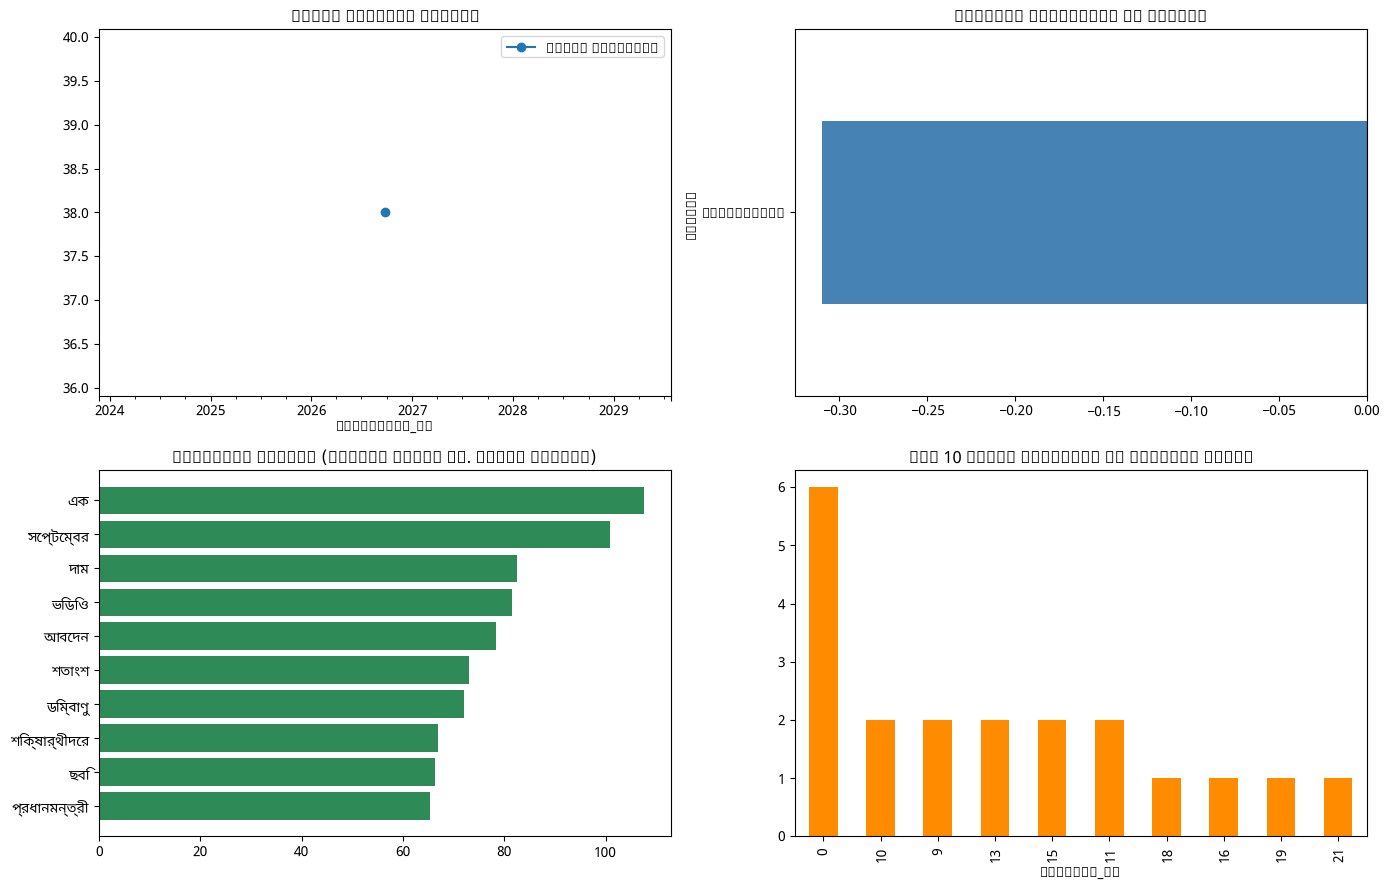

In [182]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
ax = axes[0, 0]
daily_volume.plot(ax=ax, marker="o", label="daily articles")
if not anomalies.empty:
    ax.scatter(anomalies.index, anomalies.values, color="red", zorder=5, label="anomaly")
ax.set_title("Daily article volume")
ax.legend()
ax = axes[0, 1]
sent_by_source = articles_df.groupby("source")["sentiment_score"].mean().sort_values()
sent_by_source.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Average sentiment by source")
ax.axvline(0, color="black", linewidth=0.8)
ax = axes[1, 0]
if emerging:
    terms = [t for t, s, g in emerging]
    growths = [g for t, s, g in emerging]
    ax.barh(terms[::-1], growths[::-1], color="seagreen")
ax.set_title("Emerging topics (growth ratio vs. prior window)")
ax = axes[1, 1]
cluster_sizes.head(10).plot(kind="bar", ax=ax, color="darkorange")
ax.set_title("Top 10 event clusters by article count")
ax.set_xlabel("cluster_id")

plt.tight_layout()
plt.savefig("dashboard_snapshot.png", dpi=120)
plt.show()


In [183]:
# from google.colab import drive
# drive.mount("/content/drive")
# OUTPUT_DIR = "/content/drive/MyDrive/bangla-news-intel"
OUTPUT_DIR = "."  # change to the Drive path above once mounted

articles_df.to_csv(f"{OUTPUT_DIR}/articles_processed.csv", index=False)
np.save(f"{OUTPUT_DIR}/embeddings.npy", embeddings)
print("Saved articles_processed.csv and embeddings.npy")


Saved articles_processed.csv and embeddings.npy


In [103]:
def get_daily_digest(df, date_str):
    """Filter articles for one date, group by event cluster, and print an
    organized digest: what happened, who's involved, how sentiment differs
    across sources covering the same event."""
    try:
        target_date = pd.to_datetime(date_str).date()
    except Exception:
        print(f"তারিখ বুঝতে পারিনি: '{date_str}'। YYYY-MM-DD ফরম্যাটে দিন, যেমন 2026-09-20")
        return None

    day_df = df[df["published_at"].dt.date == target_date]
    if day_df.empty:
        print(f"{target_date} তারিখে কোনো আর্টিকেল পাওয়া যায়নি।")
        return None

    print(f"\n{'='*60}")
    print(f" {target_date} তারিখের খবর — মোট {len(day_df)}টি আর্টিকেল, "
          f"{day_df['cluster_id'].nunique()}টি ভিন্ন ঘটনা")
    print(f"{'='*60}\n")

    cluster_order = day_df["cluster_id"].value_counts().index
    for cid in cluster_order:
        cluster_df = day_df[day_df.cluster_id == cid]
        sources = cluster_df["source"].unique().tolist()
        headline = cluster_df.iloc[0]["title"]

        all_ents = Counter()
        for ents in cluster_df["entities"]:
            for name, etype in (ents or []):
                all_ents[name] += 1
        top_entities = ", ".join(n for n, c in all_ents.most_common(4))

        avg_sentiment = cluster_df["sentiment_score"].mean()
        sentiment_word = ("নেতিবাচক" if avg_sentiment < -0.15
                           else ("ইতিবাচক" if avg_sentiment > 0.15 else "নিরপেক্ষ"))

        print(f"🔹 {headline}")
        print(f"   সোর্স: {', '.join(sources)} ({len(cluster_df)} আর্টিকেল)")
        if top_entities:
            print(f"   জড়িত: {top_entities}")
        print(f"   সামগ্রিক সুর: {sentiment_word} (score: {avg_sentiment:.2f})\n")

    return day_df
_ = get_daily_digest(articles_df, "2026-09-20")

2026-09-20 তারিখে কোনো আর্টিকেল পাওয়া যায়নি।


In [104]:
print(sorted(articles_df["published_at"].dt.date.unique()))

[datetime.date(2026, 9, 24)]


In [105]:
def news_chatbot():
    print("বাংলা নিউজ ইন্টেলিজেন্স চ্যাটবট — তারিখ লিখুন (YYYY-MM-DD), বের হতে 'exit' লিখুন।\n")
    while True:
        user_input = input("তারিখ: ").strip()
        if user_input.lower() in ("exit", "quit", "বের হও"):
            print("বিদায়!")
            break
        get_daily_digest(articles_df, user_input)
news_chatbot()

বাংলা নিউজ ইন্টেলিজেন্স চ্যাটবট — তারিখ লিখুন (YYYY-MM-DD), বের হতে 'exit' লিখুন।

তারিখ: 2026-9-24

 2026-09-24 তারিখের খবর — মোট 39টি আর্টিকেল, 27টি ভিন্ন ঘটনা

🔹 গণতান্ত্রিক দেশে সব ক্ষমতার উৎস জনগণ—জুনিয়র বৃত্তি পরীক্ষা–২০২৬
   সোর্স: prothomalo (8 আর্টিকেল)
   জড়িত: বাংলাদেশের, দেশের, চট্টগ্রাম বন্ধুসভা, নির্বাচন কমিশন
   সামগ্রিক সুর: ইতিবাচক (score: 0.26)

🔹 যেভাবে বদলে গেল গিফার গোত্রের ভাগ্য
   সোর্স: prothomalo (4 আর্টিকেল)
   জড়িত: আবু জরের, ##্কায়, সিরিয়ার, ##বু জর
   সামগ্রিক সুর: ইতিবাচক (score: 0.29)

🔹 কুমিল্লায় কিশোর গ্যাংবিরোধী অভিযানে আটক ৬২৪
   সোর্স: prothomalo (3 আর্টিকেল)
   জড়িত: ##ু, ##্লায়, ##ুমিল্লায়, কুমিল্লায়
   সামগ্রিক সুর: ইতিবাচক (score: 0.18)

🔹 সুষম খাদ্য দেহের বৃদ্ধি ও ক্ষয় পূরণ করে—প্রাথমিক বৃত্তি পরীক্ষা ২০২৬
   সোর্স: prothomalo (1 আর্টিকেল)
   জড়িত: প্রাথমিক, ##ীক্ষা, ২০২৬, প্রাথমিক বিজ্ঞান :
   সামগ্রিক সুর: নেতিবাচক (score: -0.52)

🔹 গাজার পুনর্গঠনে ২৪০ কোটি ডলার ব্যয়ের পরিকল্পনা ট্রাম্পের শান্তি পর্ষদের
   সোর্স: prothomalo (1 আর্

In [108]:
import os

def llm_daily_summary(df, date_str, api_key=None):
    api_key = api_key or os.environ.get("ANTHROPIC_API_KEY")
    if not api_key:
        print("ANTHROPIC_API_KEY সেট নেই — এই cell স্কিপ করা হলো।")
        return None

    day_df = get_daily_digest(df, date_str)
    if day_df is None:
        return None

    cluster_summaries = []
    for cid, cluster_df in day_df.groupby("cluster_id"):
        headline = cluster_df.iloc[0]["title"]
        sources = ", ".join(cluster_df["source"].unique())
        cluster_summaries.append(f"- {headline} (সোর্স: {sources})")

    prompt = (
        "নিচের বুলেট পয়েন্টগুলো একটা নির্দিষ্ট দিনের প্রধান বাংলা সংবাদ শিরোনাম। "
        "এগুলো দিয়ে একটা সংক্ষিপ্ত, স্বাভাবিক বাংলা ভাষার news brief লিখো (৩-৫ বাক্য), "
        "যেন একজন সম্পাদক দিনের সারসংক্ষেপ লিখছেন।\n\n" + "\n".join(cluster_summaries)
    )

    import anthropic
    client = anthropic.Anthropic(api_key=api_key)
    response = client.messages.create(
        model="claude-sonnet-4-6", max_tokens=500,
        messages=[{"role": "user", "content": prompt}],
    )
    print(response.content[0].text)
    return response.content[0].text

# Example (no-op without an API key):
# llm_daily_summary(articles_df, "2026-09-20")

In [109]:
def print_final_summary(articles_df, cluster_sizes, all_entities, daily_volume, anomalies, emerging):
    line = "=" * 70
    print(line)
    print("বাংলা নিউজ ইন্টেলিজেন্স সিস্টেম — চূড়ান্ত সারসংক্ষেপ")
    print(line)

    print(f"\nমোট আর্টিকেল সংগ্রহ করা হয়েছে: {len(articles_df)}")
    print(f"সোর্স সংখ্যা: {articles_df['source'].nunique()} ({', '.join(articles_df['source'].unique())})")
    print(f"সময়সীমা: {articles_df['published_at'].min()} থেকে {articles_df['published_at'].max()}")
    print(f"মোট ঘটনা (event cluster): {articles_df['cluster_id'].nunique()}")

    print(f"\n{'-'*70}\nবর্তমানে সবচেয়ে বড় ঘটনাগুলো (What is happening):\n{'-'*70}")
    for cid, size in cluster_sizes.head(5).items():
        headline = articles_df[articles_df.cluster_id == cid].iloc[0]["title"]
        sources = articles_df[articles_df.cluster_id == cid]["source"].unique()
        print(f"  🔹 {headline}  [{size} আর্টিকেল, {len(sources)} সোর্স]")

    print(f"\n{'-'*70}\nনতুন উঠে আসা টপিক (Emerging topics):\n{'-'*70}")
    if emerging:
        for term, score, growth in emerging[:5]:
            print(f"  • {term:<25} বৃদ্ধি: {growth:.1f}x")
    else:
        print("  (তথ্য নেই)")

    print(f"\n{'-'*70}\nসবচেয়ে বেশি আলোচিত entity:\n{'-'*70}")
    for (name, etype), count in all_entities.most_common(5):
        print(f"  • {name:<20} [{etype}]  {count} বার উল্লেখ")

    print(f"\n{'-'*70}\nসোর্স অনুযায়ী গড় sentiment:\n{'-'*70}")
    sent_by_source = articles_df.groupby("source")["sentiment_score"].mean().sort_values()
    for source, score in sent_by_source.items():
        mood = "নেতিবাচক" if score < -0.15 else ("ইতিবাচক" if score > 0.15 else "নিরপেক্ষ")
        print(f"  • {source:<20} {score:+.2f}  ({mood})")

    print(f"\n{'-'*70}\nঅস্বাভাবিক দিন (Anomalies):\n{'-'*70}")
    if len(anomalies) > 0:
        for dt, count in anomalies.items():
            baseline = daily_volume.median()
            direction = "↑ বেশি" if count > baseline else "↓ কম"
            print(f"  • {dt.date()}: {int(count)}টি আর্টিকেল ({direction} স্বাভাবিকের তুলনায়)")
    else:
        print("  কোনো অস্বাভাবিক পরিবর্তন পাওয়া যায়নি।")

    print(f"\n{line}")
    print("সম্পূর্ণ pipeline সফলভাবে চলেছে। বিস্তারিত এক্সপ্লোরেশনের জন্য উপরের সেকশনগুলো দেখুন,")
    print("   বা get_daily_digest(articles_df, 'YYYY-MM-DD') দিয়ে যেকোনো নির্দিষ্ট দিনের খবর দেখুন।")
    print(line)


print_final_summary(articles_df, cluster_sizes, all_entities, daily_volume, anomalies, emerging)

বাংলা নিউজ ইন্টেলিজেন্স সিস্টেম — চূড়ান্ত সারসংক্ষেপ

মোট আর্টিকেল সংগ্রহ করা হয়েছে: 39
সোর্স সংখ্যা: 1 (prothomalo)
সময়সীমা: 2026-09-24 00:00:00 থেকে 2026-09-24 00:00:00
মোট ঘটনা (event cluster): 27

----------------------------------------------------------------------
বর্তমানে সবচেয়ে বড় ঘটনাগুলো (What is happening):
----------------------------------------------------------------------
  🔹 গণতান্ত্রিক দেশে সব ক্ষমতার উৎস জনগণ—জুনিয়র বৃত্তি পরীক্ষা–২০২৬  [8 আর্টিকেল, 1 সোর্স]
  🔹 যেভাবে বদলে গেল গিফার গোত্রের ভাগ্য  [4 আর্টিকেল, 1 সোর্স]
  🔹 কুমিল্লায় কিশোর গ্যাংবিরোধী অভিযানে আটক ৬২৪  [3 আর্টিকেল, 1 সোর্স]
  🔹 সুষম খাদ্য দেহের বৃদ্ধি ও ক্ষয় পূরণ করে—প্রাথমিক বৃত্তি পরীক্ষা ২০২৬  [1 আর্টিকেল, 1 সোর্স]
  🔹 গাজার পুনর্গঠনে ২৪০ কোটি ডলার ব্যয়ের পরিকল্পনা ট্রাম্পের শান্তি পর্ষদের  [1 আর্টিকেল, 1 সোর্স]

----------------------------------------------------------------------
নতুন উঠে আসা টপিক (Emerging topics):
----------------------------------------------------------------------